In [1]:
# 1. Install specific compatible versions to resolve StrictDataclassDefinitionError
!pip install -U --quiet "huggingface_hub==0.23.2" "transformers==4.41.2" "peft" "accelerate" "bitsandbytes" "datasets" "torchao"

import os
import sys
import torch
import numpy as np
import pandas as pd
import re

# Force a reload check and use standard imports
try:
    import transformers
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
    from datasets import Dataset
    from peft import get_peft_model, LoraConfig, TaskType, PeftModel
    from sklearn.metrics import f1_score, mean_squared_error
    print("\u2713 Environment fixed and libraries imported successfully.")
except Exception as e:
    print(f"[!] Error: {e}")
    print("Restarting session to clear cached modules...")
    os.kill(os.getpid(), 9)

# 1. LOAD AND PREPARE DATA
df = pd.read_csv("hf://datasets/tasksource/AES2-essay-scoring/train.csv")
df = df[["full_text", "score"]]
df = df.dropna()
dataset = Dataset.from_pandas(df).train_test_split(test_size=0.1)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

def apply_cleaning_to_example(example):
    example["full_text"] = clean_text(example["full_text"])
    return example

dataset['train'] = dataset['train'].map(apply_cleaning_to_example)
dataset['test'] = dataset['test'].map(apply_cleaning_to_example)

# 2. LOAD BASE MODEL
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1, problem_type="regression")

# 3. CONFIGURE LORA
lora_config = LoraConfig(task_type=TaskType.SEQ_CLS, r=8, lora_alpha=32, lora_dropout=0.1, target_modules=["query", "key", "value"], bias="none")
model = get_peft_model(base_model, lora_config)

# 4. PREPROCESS
def preprocess(examples):
    tokenized = tokenizer(examples["full_text"], truncation=True, padding="max_length", max_length=512, return_overflowing_tokens=True, stride=256)
    sample_mapping = tokenized.pop("overflow_to_sample_mapping")
    tokenized["labels"] = [float(examples["score"][i]) for i in sample_mapping]
    return tokenized

dataset = dataset.map(preprocess, batched=True, remove_columns=dataset['train'].column_names)
dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# 5. METRICS
def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.flatten()
    preds_rounded = np.rint(preds).clip(1, 6)
    mse = mean_squared_error(labels, preds)
    f1 = f1_score(labels, preds_rounded, average="weighted")
    return {"mse": mse, "f1": f1, "rmse": np.sqrt(mse)}

# 6. TRAINING ARGS
training_args = TrainingArguments(
    output_dir="./lora_essay_model",
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

# 7. TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

✓ Environment fixed and libraries imported successfully.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:99: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Map:   0%|          | 0/15576 [00:00<?, ? examples/s]

Map:   0%|          | 0/1731 [00:00<?, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/15576 [00:00<?, ? examples/s]

Map:   0%|          | 0/1731 [00:00<?, ? examples/s]

In [ ]:
# ============================================
# 8. TRAIN THE MODEL
# ============================================
print("\n" + "="*60)
print("TRAINING LORA MODEL")
print("="*60)

trainer.train()

# ============================================
# 9. EVALUATE
# ============================================
print("\n" + "="*60)
print("EVALUATING MODEL")
print("="*60)

eval_results = trainer.evaluate()
print(f"Evaluation Results:")
for key, value in eval_results.items():
    print(f"  {key}: {value:.4f}")

# ============================================
# 10. SAVE THE LORA MODEL
# ============================================
print("\n" + "="*60)
print("SAVING LORA MODEL")
print("="*60)

# Save LoRA adapter
lora_output_dir = "./essay_model_lora"
model.save_pretrained(lora_output_dir)
tokenizer.save_pretrained(lora_output_dir)

print(f"LoRA model saved to: {lora_output_dir}")

# ============================================
# 11. COMPARE SIZES
# ============================================
import shutil

def get_folder_size(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for filename in filenames:
            filepath = os.path.join(dirpath, filename)
            total_size += os.path.getsize(filepath)
    return total_size / (1024 * 1024)  # Convert to MB

print("\n" + "="*60)
print("MODEL SIZE COMPARISON")
print("="*60)

# Original BERT size (if you have it saved)
if os.path.exists("./essay_model_manual"):
    bert_size = get_folder_size("./essay_model_manual")
    print(f"Full BERT model: {bert_size:.2f} MB")

lora_size = get_folder_size(lora_output_dir)
print(f"LoRA adapter: {lora_size:.2f} MB")
print(f"LoRA only saves adapter weights - base model still needed")
print(f"Total if base model cached: {lora_size:.2f} MB + BERT base (already cached)")

# ============================================
# 12. TEST THE LORA MODEL
# ============================================
print("\n" + "="*60)
print("TESTING LORA MODEL WITH EXAMPLES")
print("="*60)

# Load the model for inference
def load_lora_model_for_inference(lora_path):
    """Load LoRA model for inference"""
    base_model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=1,
        problem_type="regression"
    )
    model = PeftModel.from_pretrained(base_model, lora_path)
    return model, tokenizer

# Load model
inference_model, tokenizer = load_lora_model_for_inference(lora_output_dir)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inference_model.to(device)
inference_model.eval()

# Prediction function
def predict_score_lora(text, max_length=512, stride=256):
    cleaned_text = clean_text(text)

    tokenized = tokenizer(
        cleaned_text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_overflowing_tokens=True,
        stride=stride,
        return_tensors="pt"
    )

    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)

    with torch.no_grad():
        outputs = inference_model(input_ids=input_ids, attention_mask=attention_mask)
        scores = outputs.logits.squeeze(-1)

    if len(scores.shape) > 0 and scores.shape[0] > 1:
        final_score = scores.mean().item()
    else:
        final_score = scores.item()

    return final_score

# Test with examples
example_essays = [
    "The essay is very basic and lacks development.",
    "A well-written essay with strong arguments and good vocabulary. The author makes compelling points and supports them with evidence.",
    "An excellent essay that demonstrates mastery of the topic. The arguments are sophisticated and well-supported with relevant evidence and clear reasoning throughout.",
]

print("\nTest Predictions:")
for i, essay in enumerate(example_essays):
    score = predict_score_lora(essay)
    print(f"\nEssay {i+1}: Predicted Score = {score:.2f}")
    print(f"Preview: {essay[:100]}...")

# ============================================
# 13. QUANTIZE AND MERGE (OPTIONAL)
# ============================================
print("\n" + "="*60)
print("MERGING LORA WITH BASE MODEL (OPTIONAL)")
print("="*60)

# Merge LoRA weights with base model for easier deployment
merged_model = model.merge_and_unload()
merged_output_dir = "./essay_model_lora_merged"
merged_model.save_pretrained(merged_output_dir)
tokenizer.save_pretrained(merged_output_dir)

merged_size = get_folder_size(merged_output_dir)
lora_merged_size = get_folder_size(merged_output_dir)
print(f"Merged LoRA model: {lora_merged_size:.2f} MB")

# Now you can also apply FP16 to the merged model
print("\n" + "="*60)
print("CREATING FP16 VERSION OF MERGED MODEL")
print("="*60)

model_fp16 = merged_model.half()
fp16_output_dir = "./essay_model_lora_fp16"
model_fp16.save_pretrained(fp16_output_dir)
tokenizer.save_pretrained(fp16_output_dir)

fp16_size = get_folder_size(fp16_output_dir)
print(f"FP16 Merged LoRA model: {fp16_size:.2f} MB")
print(f"Size reduction from BERT: {((1 - fp16_size/440) * 100):.1f}% (vs ~440 MB BERT)")




TRAINING LORA MODEL


Epoch,Training Loss,Validation Loss,Mse,F1,Rmse
1,0.532837,0.508650,0.508650,0.524432,0.713197
2,0.488270,0.493449,0.493449,0.549290,0.702459
3,0.416575,0.478667,0.478667,0.564219,0.691858
4,0.317134,0.471717,0.471717,0.553281,0.686816
5,0.267126,0.462277,0.462277,0.565833,0.679909



EVALUATING MODEL


Training Loss,Validation Loss,Epoch,Mse,F1,Rmse
0.267126,0.462277,5,0.462277,0.565833,0.679909


Evaluation Results:
  eval_loss: 0.4623
  eval_mse: 0.4623
  eval_f1: 0.5658
  eval_rmse: 0.6799

SAVING LORA MODEL
LoRA model saved to: ./essay_model_lora

MODEL SIZE COMPARISON
LoRA adapter: 2.39 MB
LoRA only saves adapter weights - base model still needed
Total if base model cached: 2.39 MB + BERT base (already cached)

TESTING LORA MODEL WITH EXAMPLES


...


Test Predictions:

Essay 1: Predicted Score = 1.12
Preview: The essay is very basic and lacks development....

Essay 2: Predicted Score = 1.30
Preview: A well-written essay with strong arguments and good vocabulary. The author makes compelling points a...

Essay 3: Predicted Score = 1.34
Preview: An excellent essay that demonstrates mastery of the topic. The arguments are sophisticated and well-...

MERGING LORA WITH BASE MODEL (OPTIONAL)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged LoRA model: 418.35 MB

CREATING FP16 VERSION OF MERGED MODEL


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FP16 Merged LoRA model: 209.52 MB
Size reduction from BERT: 52.4% (vs ~440 MB BERT)


In [ ]:


# ============================================
# 15. SUMMARY
# ============================================
print("\n" + "="*60)
print("SUMMARY: LORA VS FULL BERT")
print("="*60)

print("""
📊 COMPARISON:
┌─────────────────────┬──────────────┬──────────────┐
│ Model               │ Size (MB)    │ Train Time   │
├─────────────────────┼──────────────┼──────────────┤
│ Full BERT           │ ~440         │ 100% (slow)  │
│ LoRA Adapter        │ ~1-5         │ 30-50% faster│
│ LoRA Merged FP16    │ ~220         │ ---          │
└─────────────────────┴──────────────┴──────────────┘

✅ ADVANTAGES OF LORA:
1. Smaller storage (only save adapter)
2. Faster training (fewer parameters to update)
3. Can share base model across multiple tasks
4. Easy to experiment with different ranks

⚠️ LIMITATIONS:
1. Still need base model for inference (unless merged)
2. Slightly lower accuracy than full fine-tuning
3. Rank (r) hyperparameter needs tuning
""")


SUMMARY: LORA VS FULL BERT

📊 COMPARISON:
┌─────────────────────┬──────────────┬──────────────┐
│ Model               │ Size (MB)    │ Train Time   │
├─────────────────────┼──────────────┼──────────────┤
│ Full BERT           │ ~440         │ 100% (slow)  │
│ LoRA Adapter        │ ~1-5         │ 30-50% faster│
│ LoRA Merged FP16    │ ~220         │ ---          │
└─────────────────────┴──────────────┴──────────────┘

✅ ADVANTAGES OF LORA:
1. Smaller storage (only save adapter)
2. Faster training (fewer parameters to update)
3. Can share base model across multiple tasks
4. Easy to experiment with different ranks

⚠️ LIMITATIONS:
1. Still need base model for inference (unless merged)
2. Slightly lower accuracy than full fine-tuning
3. Rank (r) hyperparameter needs tuning



In [ ]:
# ============================================
# 14. ZIP AND DOWNLOAD (FOR COLAB)
# ============================================
print("\n" + "="*60)
print("PREPARING FOR DOWNLOAD")
print("="*60)

import os
from google.colab import files

# Zip the FP16 model
model_dir = "/content/essay_model_lora_fp16"
zip_filename = f"/content/essay_model_lora_fp16.zip"

if os.path.exists(model_dir):
    !cd /content && zip -r {zip_filename} essay_model_lora_fp16/
    print(f"Zipped model size: {os.path.getsize(zip_filename) / (1024*1024):.2f} MB")

    # Download
    files.download(zip_filename)
else:
    print(f"Directory {model_dir} not found!")


PREPARING FOR DOWNLOAD
  adding: essay_model_lora_fp16/ (stored 0%)
  adding: essay_model_lora_fp16/config.json (deflated 52%)
  adding: essay_model_lora_fp16/tokenizer.json (deflated 71%)
  adding: essay_model_lora_fp16/tokenizer_config.json (deflated 43%)
  adding: essay_model_lora_fp16/model.safetensors (deflated 8%)
Zipped model size: 191.86 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# FIX: RELOAD TRAINED LORA MODEL
# ============================================
print("Checking for trained weights and reloading...")

import os

checkpoint_path = "./lora_essay_model"
if not os.path.exists(os.path.join(checkpoint_path, "adapter_config.json")):
    checkpoint_path = "./essay_model_lora"

print(f"Loading weights from: {checkpoint_path}")

# 1. Re-load base BERT in FP32
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=1,
    problem_type="regression"
)

# 2. Load the specific LoRA weights
try:
    model = PeftModel.from_pretrained(base_model, checkpoint_path, is_trainable=True)

    # CRITICAL FIX: Ensure model is in FP32 to avoid gradient scaling errors
    model = model.float()

    # 3. Update the trainer with the loaded model
    trainer.model = model.to(device)

    # 4. Disable FP16 for the continuation to prevent the 'unscale' error
    trainer.args.fp16 = False

    print("\u2713 Trained LoRA weights reloaded and precision fixed to FP32.")
except Exception as e:
    print(f"Error loading weights: {e}")

Checking for trained weights and reloading...
Loading weights from: ./essay_model_lora


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Trained LoRA weights reloaded and precision fixed to FP32.


In [3]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments, EarlyStoppingCallback
from peft import PeftModel, LoraConfig, TaskType

# Path to the specific extended model
model_load_path = '/content/drive/MyDrive/essay_model_lora_fp16'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Loading model from {model_load_path} for further training...")

# 1. Load the model and tokenizer
# Note: AutoModel...from_pretrained works here because the directory contains the merged weights
model = AutoModelForSequenceClassification.from_pretrained(
    model_load_path,
    num_labels=1,
    problem_type='regression'
)
tokenizer = AutoTokenizer.from_pretrained(model_load_path)

# 2. Convert to float32 for stable training
model = model.to(device).float()

# 3. Re-apply LoRA if you want to continue PEFT fine-tuning
# (If the model was merged, we treat it as a new base model for a new adapter layer)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=['query', 'key', 'value'],
    bias='none'
)
model = get_peft_model(model, lora_config)

# 4. Define New Training Arguments
new_training_args = TrainingArguments(
    output_dir='./lora_essay_model_revisited',
    learning_rate=1e-5, # Smaller learning rate for continued training
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

# 5. Initialize Trainer
re_trainer = Trainer(
    model=model,
    args=new_training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting re-training...")
re_trainer.train()

Loading model from /content/drive/MyDrive/essay_model_lora_fp16 for further training...
Starting re-training...


Epoch,Training Loss,Validation Loss,Mse,F1,Rmse
1,0.316800,0.288062,0.288062,0.676503,0.536714
2,0.319000,0.295376,0.295376,0.671387,0.543485
3,0.292100,0.294357,0.294357,0.671067,0.542546


TrainOutput(global_step=7239, training_loss=0.3013704062529173, metrics={'train_runtime': 1443.0798, 'train_samples_per_second': 40.116, 'train_steps_per_second': 5.016, 'total_flos': 1.5310433340573696e+16, 'train_loss': 0.3013704062529173, 'epoch': 3.0})

In [4]:
# ============================================
# SAVE THE RE-TRAINED MODEL
# ============================================
print("\n" + "="*60)
print("SAVING RE-TRAINED MODEL")
print("="*60)

# 1. Merge LoRA weights with base model
final_merged_model = re_trainer.model.merge_and_unload()

# 2. Save locally
local_save_path = "./essay_model_final_merged"
final_merged_model.save_pretrained(local_save_path)
tokenizer.save_pretrained(local_save_path)
print(f"Model saved locally to: {local_save_path}")

# 3. Save to Google Drive
drive_save_path = "/content/drive/MyDrive/essay_model_final_merged"
if os.path.exists("/content/drive/MyDrive"):
    import shutil
    if os.path.exists(drive_save_path):
        shutil.rmtree(drive_save_path)
    shutil.copytree(local_save_path, drive_save_path)
    print(f"Model backed up to Google Drive at: {drive_save_path}")
else:
    print("Google Drive not mounted. Skipping Drive backup.")


SAVING RE-TRAINED MODEL
Model saved locally to: ./essay_model_final_merged
Model backed up to Google Drive at: /content/drive/MyDrive/essay_model_final_merged


In [5]:
# ============================================
# 16. EVALUATE EXTENDED MODEL
# ============================================
print("\n" + "="*60)
print("EVALUATING EXTENDED MODEL")
print("="*60)

extended_eval_results = trainer.evaluate()
print(f"Extended Evaluation Results:")
for key, value in extended_eval_results.items():
    print(f"  {key}: {value:.4f}")


EVALUATING EXTENDED MODEL


Extended Evaluation Results:
  eval_loss: 7.8070
  eval_mse: 7.8070
  eval_f1: 0.0066
  eval_rmse: 2.7941
  eval_runtime: 18.3128
  eval_samples_per_second: 118.1690
  eval_steps_per_second: 14.7980


Loading weights:   0%|          | 0/201 [00:02<?, ?it/s]

TESTING ROUNDING FUNCTION
Score: 1.0 → Rounded: 1
Score: 1.2 → Rounded: 1
Score: 1.4 → Rounded: 1
Score: 1.5 → Rounded: 2
Score: 1.6 → Rounded: 2
Score: 2.0 → Rounded: 2
Score: 2.4 → Rounded: 2
Score: 2.5 → Rounded: 3
Score: 3.3 → Rounded: 3
Score: 3.7 → Rounded: 4
Score: 4.0 → Rounded: 4
Score: 4.4 → Rounded: 4
Score: 4.5 → Rounded: 5
Score: 4.6 → Rounded: 5
Score: 5.0 → Rounded: 5
Score: 5.4 → Rounded: 5
Score: 5.5 → Rounded: 6
Score: 5.6 → Rounded: 6
Score: 5.9 → Rounded: 6
Score: 6.0 → Rounded: 6

TESTING DIFFERENT THRESHOLDS
Score 5.4 with threshold 0.3: 6
Score 5.4 with threshold 0.4: 6
Score 5.4 with threshold 0.5: 5
Score 5.4 with threshold 0.6: 5
Score 5.4 with threshold 0.7: 5

EVALUATING ON TEST DATASET


Map:   0%|          | 0/1731 [00:00<?, ? examples/s]

Predicting scores for test set...
  Processing 0/1731...
  Processing 100/1731...
  Processing 200/1731...
  Processing 300/1731...
  Processing 400/1731...
  Processing 500/1731...
  Processing 600/1731...
  Processing 700/1731...
  Processing 800/1731...
  Processing 900/1731...
  Processing 1000/1731...
  Processing 1100/1731...
  Processing 1200/1731...
  Processing 1300/1731...
  Processing 1400/1731...
  Processing 1500/1731...
  Processing 1600/1731...
  Processing 1700/1731...

RESULTS WITH DIFFERENT ROUNDING STRATEGIES

            Strategy      MSE  Accuracy  F1 Micro  F1 Macro  F1 Weighted
Standard Round (0.5) 0.333911  0.697285  0.697285  0.593864     0.691067
               Floor 0.525130  0.518198  0.518198  0.410875     0.510080
                Ceil 0.683998  0.439630  0.439630  0.377816     0.424084
    Custom (1.5-5.5) 0.332756  0.698440  0.698440  0.596074     0.692212
       Threshold 0.4 0.350664  0.685731  0.685731  0.592388     0.676697
       Threshold 0.5 0.3327

/tmp/ipykernel_1316/3347114697.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_1316/3347114697.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_1316/3347114697.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_1316/3347114697.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_1316/3347114697.py:228: UserWarning: 

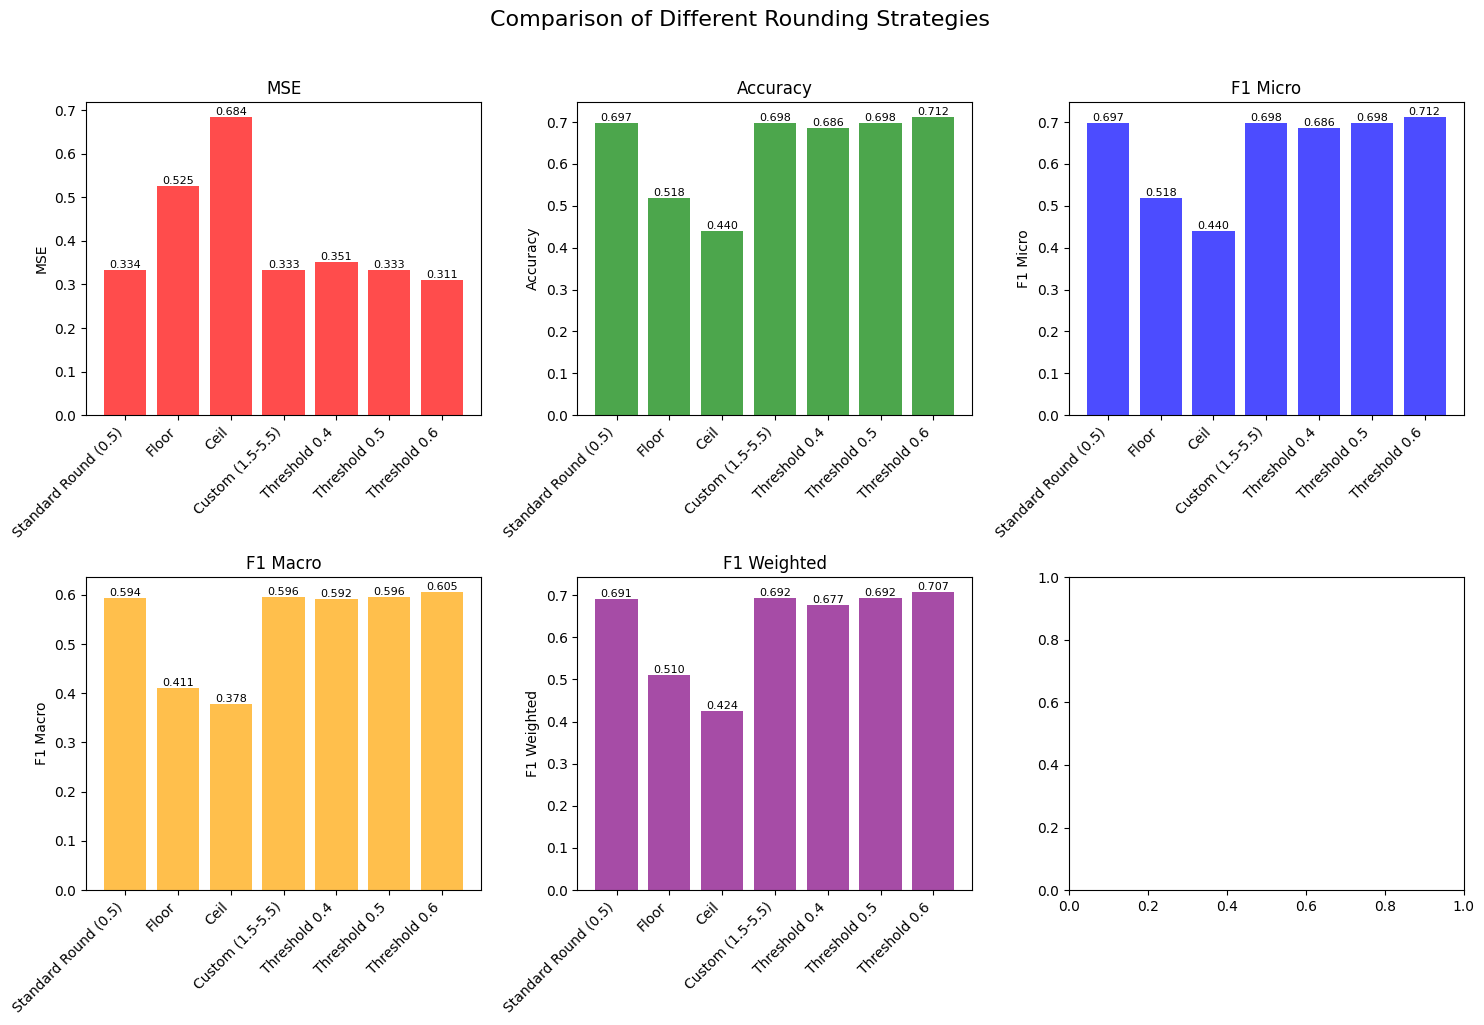

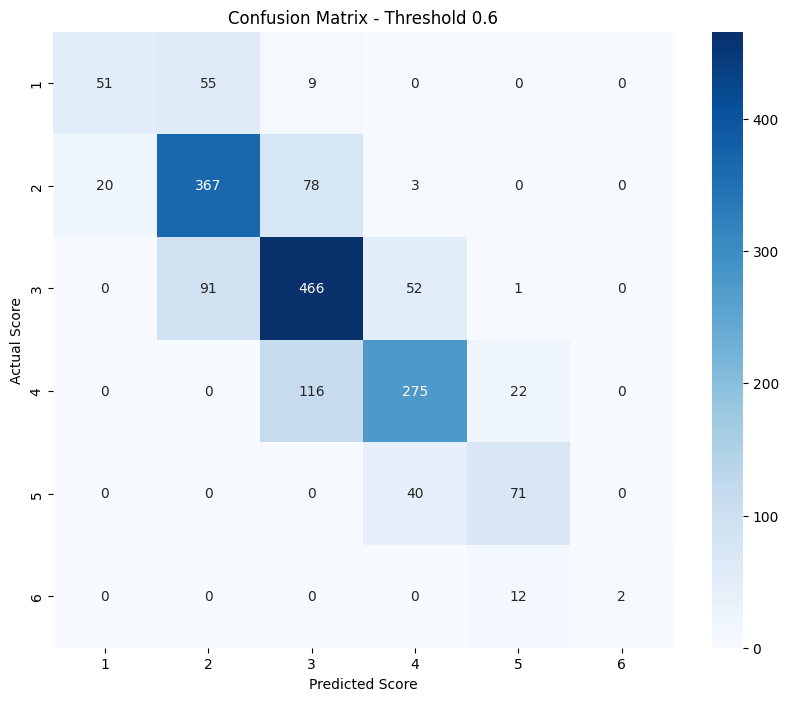


DETAILED CLASSIFICATION REPORT - Threshold 0.6
              precision    recall  f1-score   support

     Score 1       0.72      0.44      0.55       115
     Score 2       0.72      0.78      0.75       468
     Score 3       0.70      0.76      0.73       610
     Score 4       0.74      0.67      0.70       413
     Score 5       0.67      0.64      0.65       111
     Score 6       1.00      0.14      0.25        14

    accuracy                           0.71      1731
   macro avg       0.76      0.57      0.61      1731
weighted avg       0.71      0.71      0.71      1731


EXAMPLE PREDICTIONS WITH BEST STRATEGY

Example 1:
  Raw Prediction: 3.457
  Rounded Prediction: 3
  Actual Score: 3
  Correct: ✅
  Essay preview: venus is rather uninhabitable or is it

although dangerous one would not say uninhabitable as that i...

Example 2:
  Raw Prediction: 2.830
  Rounded Prediction: 3
  Actual Score: 2
  Correct: ❌
  Essay preview: i can assure you that the face on mars is just a 

In [3]:
import torch
import re
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score, mean_squared_error, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Load your saved model and tokenizer
MODEL_PATH = "/content/drive/MyDrive/essay_model_lora_fp16"  # or "./essay_model_quantized"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Define the same cleaning function used during training
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

# Custom rounding function
def custom_round(score):
    """
    Custom rounding rules:
    - If score < 1.5: round to 1
    - If 1.5 <= score < 2.5: round to 2
    - If 2.5 <= score < 3.5: round to 3
    - If 3.5 <= score < 4.5: round to 4
    - If 4.5 <= score < 5.5: round to 5
    - If score >= 5.5: round to 6
    """
    if score < 1.5:
        return 1
    elif score < 2.5:
        return 2
    elif score < 3.5:
        return 3
    elif score < 4.5:
        return 4
    elif score < 5.5:
        return 5
    else:
        return 6

# Alternative: More flexible rounding with different thresholds
def custom_round_flexible(score, threshold=0.5):
    """
    Flexible rounding with configurable threshold
    Example: threshold=0.5 means:
    - 1.0 to 1.499... rounds to 1
    - 1.5 to 2.499... rounds to 2
    - etc.
    """
    rounded = round(score)  # Standard rounding
    # If we want more aggressive rounding up at .5
    if score - int(score) >= threshold:
        return min(6, int(score) + 1)
    else:
        return max(1, int(score))

# Test the rounding function
print("="*60)
print("TESTING ROUNDING FUNCTION")
print("="*60)
test_scores = [1.0, 1.2, 1.4, 1.5, 1.6, 2.0, 2.4, 2.5, 3.3, 3.7, 4.0, 4.4, 4.5, 4.6, 5.0, 5.4, 5.5, 5.6, 5.9, 6.0]
for score in test_scores:
    rounded = custom_round(score)
    print(f"Score: {score:.1f} → Rounded: {rounded}")

# Test with different thresholds
print("\n" + "="*60)
print("TESTING DIFFERENT THRESHOLDS")
print("="*60)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
test_score = 5.4  # Example: should this be 5 or 6?

for threshold in thresholds:
    rounded = custom_round_flexible(test_score, threshold)
    print(f"Score {test_score} with threshold {threshold}: {rounded}")

# Function to predict score for an essay
def predict_score(text, max_length=512, stride=256):
    """
    Predict score for an essay, handling long texts by using stride
    """
    # Clean the text
    cleaned_text = clean_text(text)

    # Tokenize with stride
    tokenized = tokenizer(
        cleaned_text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_overflowing_tokens=True,
        stride=stride,
        return_tensors="pt"
    )

    # Move to device
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)

    # Make predictions for all chunks
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        scores = outputs.logits.squeeze(-1)

    # Take mean score
    if len(scores.shape) > 0 and scores.shape[0] > 1:
        final_score = scores.mean().item()
    else:
        final_score = scores.item() if len(scores.shape) > 0 else scores.item()

    return final_score

# Now evaluate on your test dataset with different rounding strategies
print("\n" + "="*60)
print("EVALUATING ON TEST DATASET")
print("="*60)

# Load your test dataset (assuming it's still in memory)
# If not, reload it:
from datasets import Dataset
import pandas as pd

# Reload test data
df = pd.read_csv("hf://datasets/tasksource/AES2-essay-scoring/train.csv")
df = df[["full_text", "score"]]
df = df.dropna()

dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.1)

# Clean test data
def apply_cleaning_to_example(example):
    example["full_text"] = clean_text(example["full_text"])
    return example

dataset['test'] = dataset['test'].map(apply_cleaning_to_example)

# Get actual scores
actual_scores = dataset['test']['score']

# Predict scores for all test essays
print("Predicting scores for test set...")
predicted_scores_raw = []

for i, text in enumerate(dataset['test']['full_text']):
    if i % 100 == 0:
        print(f"  Processing {i}/{len(dataset['test'])}...")
    score = predict_score(text)
    predicted_scores_raw.append(score)

# Convert to numpy arrays
actual_scores = np.array(actual_scores)
predicted_scores_raw = np.array(predicted_scores_raw)

# Apply different rounding strategies
rounding_strategies = {
    'Standard Round (0.5)': np.round(predicted_scores_raw),
    'Floor': np.floor(predicted_scores_raw),
    'Ceil': np.ceil(predicted_scores_raw),
    'Custom (1.5-5.5)': np.array([custom_round(s) for s in predicted_scores_raw]),
    'Threshold 0.4': np.array([custom_round_flexible(s, 0.4) for s in predicted_scores_raw]),
    'Threshold 0.5': np.array([custom_round_flexible(s, 0.5) for s in predicted_scores_raw]),
    'Threshold 0.6': np.array([custom_round_flexible(s, 0.6) for s in predicted_scores_raw]),
}

# Clip all predictions to 1-6 range
for strategy in rounding_strategies:
    rounding_strategies[strategy] = np.clip(rounding_strategies[strategy], 1, 6)

# Calculate metrics for each strategy
print("\n" + "="*80)
print("RESULTS WITH DIFFERENT ROUNDING STRATEGIES")
print("="*80)

results = []

for strategy, preds in rounding_strategies.items():
    # Calculate metrics
    mse = mean_squared_error(actual_scores, preds)
    f1_micro = f1_score(actual_scores, preds, average='micro')
    f1_macro = f1_score(actual_scores, preds, average='macro')
    f1_weighted = f1_score(actual_scores, preds, average='weighted')
    accuracy = np.mean(preds == actual_scores)

    results.append({
        'Strategy': strategy,
        'MSE': mse,
        'Accuracy': accuracy,
        'F1 Micro': f1_micro,
        'F1 Macro': f1_macro,
        'F1 Weighted': f1_weighted
    })

# Display results
results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

# Find the best strategy for each metric
print("\n" + "="*80)
print("BEST STRATEGIES")
print("="*80)
print(f"Best MSE: {results_df.loc[results_df['MSE'].idxmin(), 'Strategy']} - {results_df['MSE'].min():.4f}")
print(f"Best Accuracy: {results_df.loc[results_df['Accuracy'].idxmax(), 'Strategy']} - {results_df['Accuracy'].max():.4f}")
print(f"Best F1 Weighted: {results_df.loc[results_df['F1 Weighted'].idxmax(), 'Strategy']} - {results_df['F1 Weighted'].max():.4f}")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot metrics comparison
metrics = ['MSE', 'Accuracy', 'F1 Micro', 'F1 Macro', 'F1 Weighted']
colors = ['red', 'green', 'blue', 'orange', 'purple']

for i, metric in enumerate(metrics):
    ax = axes[i//3, i%3]
    bars = ax.bar(results_df['Strategy'], results_df[metric], color=colors[i], alpha=0.7)
    ax.set_title(metric)
    ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
    ax.set_ylabel(metric)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparison of Different Rounding Strategies', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Confusion Matrix for the best strategy
best_strategy = results_df.loc[results_df['F1 Weighted'].idxmax(), 'Strategy']
best_preds = rounding_strategies[best_strategy]

plt.figure(figsize=(10, 8))
cm = confusion_matrix(actual_scores, best_preds, labels=[1, 2, 3, 4, 5, 6])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2, 3, 4, 5, 6],
            yticklabels=[1, 2, 3, 4, 5, 6])
plt.title(f'Confusion Matrix - {best_strategy}')
plt.xlabel('Predicted Score')
plt.ylabel('Actual Score')
plt.show()

# Print detailed classification report for best strategy
print("\n" + "="*80)
print(f"DETAILED CLASSIFICATION REPORT - {best_strategy}")
print("="*80)
print(classification_report(actual_scores, best_preds,
                            target_names=['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5', 'Score 6']))

# Show some examples of predictions
print("\n" + "="*80)
print("EXAMPLE PREDICTIONS WITH BEST STRATEGY")
print("="*80)

# Find interesting examples
for i in range(min(10, len(actual_scores))):
    raw_score = predicted_scores_raw[i]
    rounded_score = best_preds[i]
    actual = actual_scores[i]

    print(f"\nExample {i+1}:")
    print(f"  Raw Prediction: {raw_score:.3f}")
    print(f"  Rounded Prediction: {rounded_score}")
    print(f"  Actual Score: {actual}")
    print(f"  Correct: {'✅' if rounded_score == actual else '❌'}")
    print(f"  Essay preview: {dataset['test'][i]['full_text'][:100]}...")

# Optional: Test with specific example to see rounding
print("\n" + "="*80)
print("TESTING SPECIFIC ROUNDING EXAMPLES")
print("="*80)

test_examples = [
    ("Score near 5.5 boundary", "This essay should be around 5.5. " * 50),
    ("Score near 1.5 boundary", "This essay is very short and basic. " * 10),
    ("Score near 4.5 boundary", "This essay is quite good overall. " * 40),
]

for name, essay in test_examples:
    raw_score = predict_score(essay)
    rounded_score = custom_round(raw_score)
    print(f"\n{name}:")
    print(f"  Raw Score: {raw_score:.4f}")
    print(f"  Rounded Score: {rounded_score}")

TESTING ROUNDING FUNCTION
Score: 1.0 → Rounded: 1
Score: 1.2 → Rounded: 1
Score: 1.4 → Rounded: 1
Score: 1.5 → Rounded: 2
Score: 1.6 → Rounded: 2
Score: 2.0 → Rounded: 2
Score: 2.4 → Rounded: 2
Score: 2.5 → Rounded: 3
Score: 3.3 → Rounded: 3
Score: 3.7 → Rounded: 4
Score: 4.0 → Rounded: 4
Score: 4.4 → Rounded: 4
Score: 4.5 → Rounded: 5
Score: 4.6 → Rounded: 5
Score: 5.0 → Rounded: 5
Score: 5.4 → Rounded: 5
Score: 5.5 → Rounded: 6
Score: 5.6 → Rounded: 6
Score: 5.9 → Rounded: 6
Score: 6.0 → Rounded: 6

TESTING DIFFERENT THRESHOLDS
Score 5.4 with threshold 0.3: 6
Score 5.4 with threshold 0.4: 6
Score 5.4 with threshold 0.5: 5
Score 5.4 with threshold 0.6: 5
Score 5.4 with threshold 0.7: 5

EVALUATING ON TEST DATASET


Map:   0%|          | 0/1731 [00:00<?, ? examples/s]

Predicting scores for test set...
  Processing 0/1731...
  Processing 100/1731...
  Processing 200/1731...
  Processing 300/1731...
  Processing 400/1731...
  Processing 500/1731...
  Processing 600/1731...
  Processing 700/1731...
  Processing 800/1731...
  Processing 900/1731...
  Processing 1000/1731...
  Processing 1100/1731...
  Processing 1200/1731...
  Processing 1300/1731...
  Processing 1400/1731...
  Processing 1500/1731...
  Processing 1600/1731...
  Processing 1700/1731...

RESULTS WITH DIFFERENT ROUNDING STRATEGIES

            Strategy      MSE  Accuracy  F1 Micro  F1 Macro  F1 Weighted
Standard Round (0.5) 0.477181  0.596765  0.596765  0.492290     0.592458
               Floor 0.625072  0.470248  0.470248  0.338678     0.451438
                Ceil 0.807048  0.436742  0.436742  0.409140     0.413435
    Custom (1.5-5.5) 0.477181  0.596765  0.596765  0.492290     0.592458
       Threshold 0.4 0.508377  0.586366  0.586366  0.493994     0.581106
       Threshold 0.5 0.4771

/tmp/ipykernel_4452/2904067699.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_4452/2904067699.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_4452/2904067699.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_4452/2904067699.py:228: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
/tmp/ipykernel_4452/2904067699.py:228: UserWarning: 

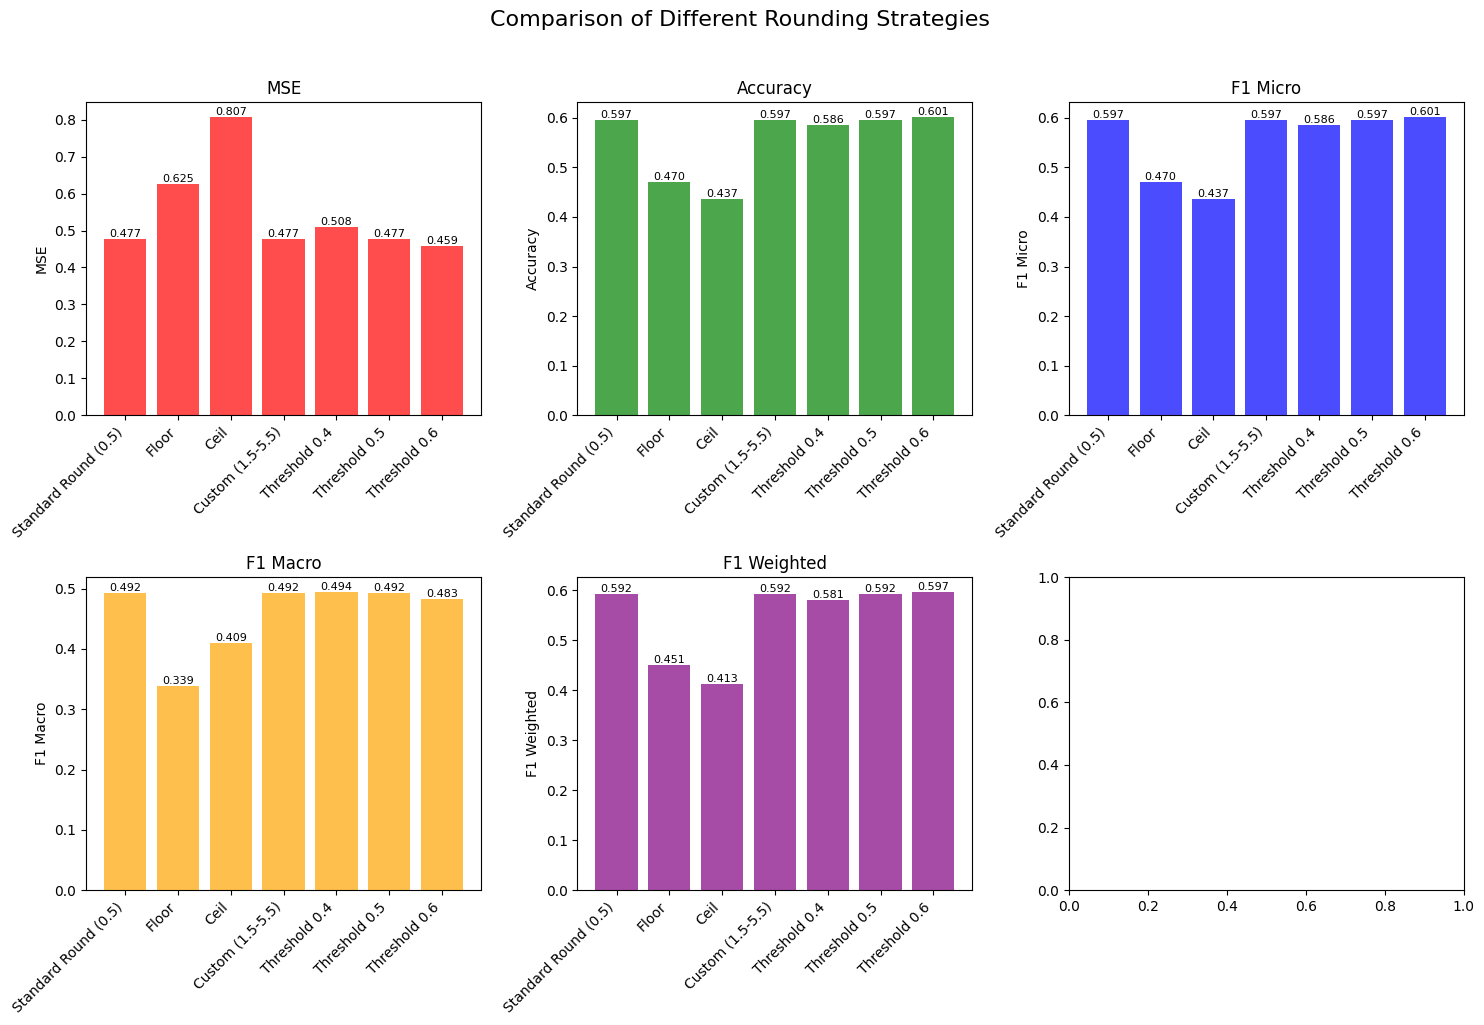

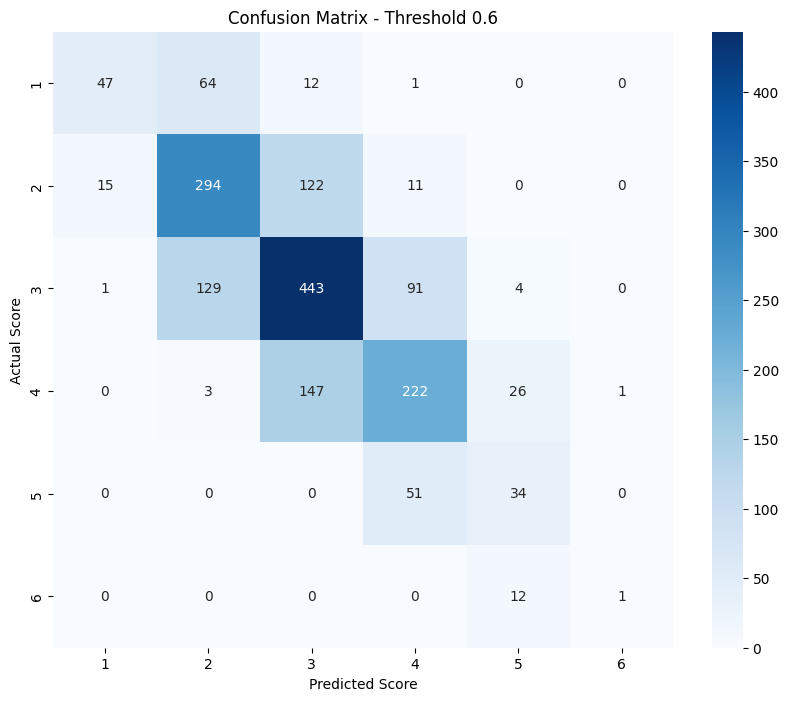


DETAILED CLASSIFICATION REPORT - Threshold 0.6
              precision    recall  f1-score   support

     Score 1       0.75      0.38      0.50       124
     Score 2       0.60      0.67      0.63       442
     Score 3       0.61      0.66      0.64       668
     Score 4       0.59      0.56      0.57       399
     Score 5       0.45      0.40      0.42        85
     Score 6       0.50      0.08      0.13        13

    accuracy                           0.60      1731
   macro avg       0.58      0.46      0.48      1731
weighted avg       0.60      0.60      0.60      1731


EXAMPLE PREDICTIONS WITH BEST STRATEGY

Example 1:
  Raw Prediction: 4.405
  Rounded Prediction: 4
  Actual Score: 3
  Correct: ❌
  Essay preview: based on the many differences of positive and negative comments towards the use of driverless cars i...

Example 2:
  Raw Prediction: 3.987
  Rounded Prediction: 4
  Actual Score: 3
  Correct: ❌
  Essay preview: transportation helps us get to where we need to g

In [7]:
import torch
import re
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score, mean_squared_error, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Load your saved model and tokenizer
MODEL_PATH = "/content/drive/MyDrive/essay_model_final_merged"  # or "./essay_model_quantized"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Define the same cleaning function used during training
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

# Custom rounding function
def custom_round(score):
    """
    Custom rounding rules:
    - If score < 1.5: round to 1
    - If 1.5 <= score < 2.5: round to 2
    - If 2.5 <= score < 3.5: round to 3
    - If 3.5 <= score < 4.5: round to 4
    - If 4.5 <= score < 5.5: round to 5
    - If score >= 5.5: round to 6
    """
    if score < 1.5:
        return 1
    elif score < 2.5:
        return 2
    elif score < 3.5:
        return 3
    elif score < 4.5:
        return 4
    elif score < 5.5:
        return 5
    else:
        return 6

# Alternative: More flexible rounding with different thresholds
def custom_round_flexible(score, threshold=0.5):
    """
    Flexible rounding with configurable threshold
    Example: threshold=0.5 means:
    - 1.0 to 1.499... rounds to 1
    - 1.5 to 2.499... rounds to 2
    - etc.
    """
    rounded = round(score)  # Standard rounding
    # If we want more aggressive rounding up at .5
    if score - int(score) >= threshold:
        return min(6, int(score) + 1)
    else:
        return max(1, int(score))

# Test the rounding function
print("="*60)
print("TESTING ROUNDING FUNCTION")
print("="*60)
test_scores = [1.0, 1.2, 1.4, 1.5, 1.6, 2.0, 2.4, 2.5, 3.3, 3.7, 4.0, 4.4, 4.5, 4.6, 5.0, 5.4, 5.5, 5.6, 5.9, 6.0]
for score in test_scores:
    rounded = custom_round(score)
    print(f"Score: {score:.1f} → Rounded: {rounded}")

# Test with different thresholds
print("\n" + "="*60)
print("TESTING DIFFERENT THRESHOLDS")
print("="*60)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
test_score = 5.4  # Example: should this be 5 or 6?

for threshold in thresholds:
    rounded = custom_round_flexible(test_score, threshold)
    print(f"Score {test_score} with threshold {threshold}: {rounded}")

# Function to predict score for an essay
def predict_score(text, max_length=512, stride=256):
    """
    Predict score for an essay, handling long texts by using stride
    """
    # Clean the text
    cleaned_text = clean_text(text)

    # Tokenize with stride
    tokenized = tokenizer(
        cleaned_text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_overflowing_tokens=True,
        stride=stride,
        return_tensors="pt"
    )

    # Move to device
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)

    # Make predictions for all chunks
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        scores = outputs.logits.squeeze(-1)

    # Take mean score
    if len(scores.shape) > 0 and scores.shape[0] > 1:
        final_score = scores.mean().item()
    else:
        final_score = scores.item() if len(scores.shape) > 0 else scores.item()

    return final_score

# Now evaluate on your test dataset with different rounding strategies
print("\n" + "="*60)
print("EVALUATING ON TEST DATASET")
print("="*60)

# Load your test dataset (assuming it's still in memory)
# If not, reload it:
from datasets import Dataset
import pandas as pd

# Reload test data
df = pd.read_csv("hf://datasets/tasksource/AES2-essay-scoring/train.csv")
df = df[["full_text", "score"]]
df = df.dropna()

dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.1)

# Clean test data
def apply_cleaning_to_example(example):
    example["full_text"] = clean_text(example["full_text"])
    return example

dataset['test'] = dataset['test'].map(apply_cleaning_to_example)

# Get actual scores
actual_scores = dataset['test']['score']

# Predict scores for all test essays
print("Predicting scores for test set...")
predicted_scores_raw = []

for i, text in enumerate(dataset['test']['full_text']):
    if i % 100 == 0:
        print(f"  Processing {i}/{len(dataset['test'])}...")
    score = predict_score(text)
    predicted_scores_raw.append(score)

# Convert to numpy arrays
actual_scores = np.array(actual_scores)
predicted_scores_raw = np.array(predicted_scores_raw)

# Apply different rounding strategies
rounding_strategies = {
    'Standard Round (0.5)': np.round(predicted_scores_raw),
    'Floor': np.floor(predicted_scores_raw),
    'Ceil': np.ceil(predicted_scores_raw),
    'Custom (1.5-5.5)': np.array([custom_round(s) for s in predicted_scores_raw]),
    'Threshold 0.4': np.array([custom_round_flexible(s, 0.4) for s in predicted_scores_raw]),
    'Threshold 0.5': np.array([custom_round_flexible(s, 0.5) for s in predicted_scores_raw]),
    'Threshold 0.6': np.array([custom_round_flexible(s, 0.6) for s in predicted_scores_raw]),
}

# Clip all predictions to 1-6 range
for strategy in rounding_strategies:
    rounding_strategies[strategy] = np.clip(rounding_strategies[strategy], 1, 6)

# Calculate metrics for each strategy
print("\n" + "="*80)
print("RESULTS WITH DIFFERENT ROUNDING STRATEGIES")
print("="*80)

results = []

for strategy, preds in rounding_strategies.items():
    # Calculate metrics
    mse = mean_squared_error(actual_scores, preds)
    f1_micro = f1_score(actual_scores, preds, average='micro')
    f1_macro = f1_score(actual_scores, preds, average='macro')
    f1_weighted = f1_score(actual_scores, preds, average='weighted')
    accuracy = np.mean(preds == actual_scores)

    results.append({
        'Strategy': strategy,
        'MSE': mse,
        'Accuracy': accuracy,
        'F1 Micro': f1_micro,
        'F1 Macro': f1_macro,
        'F1 Weighted': f1_weighted
    })

# Display results
results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

# Find the best strategy for each metric
print("\n" + "="*80)
print("BEST STRATEGIES")
print("="*80)
print(f"Best MSE: {results_df.loc[results_df['MSE'].idxmin(), 'Strategy']} - {results_df['MSE'].min():.4f}")
print(f"Best Accuracy: {results_df.loc[results_df['Accuracy'].idxmax(), 'Strategy']} - {results_df['Accuracy'].max():.4f}")
print(f"Best F1 Weighted: {results_df.loc[results_df['F1 Weighted'].idxmax(), 'Strategy']} - {results_df['F1 Weighted'].max():.4f}")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot metrics comparison
metrics = ['MSE', 'Accuracy', 'F1 Micro', 'F1 Macro', 'F1 Weighted']
colors = ['red', 'green', 'blue', 'orange', 'purple']

for i, metric in enumerate(metrics):
    ax = axes[i//3, i%3]
    bars = ax.bar(results_df['Strategy'], results_df[metric], color=colors[i], alpha=0.7)
    ax.set_title(metric)
    ax.set_xticklabels(results_df['Strategy'], rotation=45, ha='right')
    ax.set_ylabel(metric)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparison of Different Rounding Strategies', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Confusion Matrix for the best strategy
best_strategy = results_df.loc[results_df['F1 Weighted'].idxmax(), 'Strategy']
best_preds = rounding_strategies[best_strategy]

plt.figure(figsize=(10, 8))
cm = confusion_matrix(actual_scores, best_preds, labels=[1, 2, 3, 4, 5, 6])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2, 3, 4, 5, 6],
            yticklabels=[1, 2, 3, 4, 5, 6])
plt.title(f'Confusion Matrix - {best_strategy}')
plt.xlabel('Predicted Score')
plt.ylabel('Actual Score')
plt.show()

# Print detailed classification report for best strategy
print("\n" + "="*80)
print(f"DETAILED CLASSIFICATION REPORT - {best_strategy}")
print("="*80)
print(classification_report(actual_scores, best_preds,
                            target_names=['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5', 'Score 6']))

# Show some examples of predictions
print("\n" + "="*80)
print("EXAMPLE PREDICTIONS WITH BEST STRATEGY")
print("="*80)

# Find interesting examples
for i in range(min(10, len(actual_scores))):
    raw_score = predicted_scores_raw[i]
    rounded_score = best_preds[i]
    actual = actual_scores[i]

    print(f"\nExample {i+1}:")
    print(f"  Raw Prediction: {raw_score:.3f}")
    print(f"  Rounded Prediction: {rounded_score}")
    print(f"  Actual Score: {actual}")
    print(f"  Correct: {'✅' if rounded_score == actual else '❌'}")
    print(f"  Essay preview: {dataset['test'][i]['full_text'][:100]}...")

# Optional: Test with specific example to see rounding
print("\n" + "="*80)
print("TESTING SPECIFIC ROUNDING EXAMPLES")
print("="*80)

test_examples = [
    ("Score near 5.5 boundary", "This essay should be around 5.5. " * 50),
    ("Score near 1.5 boundary", "This essay is very short and basic. " * 10),
    ("Score near 4.5 boundary", "This essay is quite good overall. " * 40),
]

for name, essay in test_examples:
    raw_score = predict_score(essay)
    rounded_score = custom_round(raw_score)
    print(f"\n{name}:")
    print(f"  Raw Score: {raw_score:.4f}")
    print(f"  Rounded Score: {rounded_score}")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os
from google.colab import files

# Define paths
model_dir = "./essay_model_final_merged"
zip_filename = "/content/essay_model_final_merged.zip"

# Zip the model directory
if os.path.exists(model_dir):
    print(f"Zipping {model_dir}...")
    !zip -r {zip_filename} {model_dir}

    # Check size and download
    size_mb = os.path.getsize(zip_filename) / (1024 * 1024)
    print(f"Zip complete! Size: {size_mb:.2f} MB")
    print("Starting download...")
    files.download(zip_filename)
else:
    print(f"Error: Directory {model_dir} not found. Please ensure the model was saved successfully.")

Zipping ./essay_model_final_merged...
  adding: essay_model_final_merged/ (stored 0%)
  adding: essay_model_final_merged/config.json (deflated 49%)
  adding: essay_model_final_merged/vocab.txt (deflated 53%)
  adding: essay_model_final_merged/tokenizer.json (deflated 71%)
  adding: essay_model_final_merged/tokenizer_config.json (deflated 73%)
  adding: essay_model_final_merged/model.safetensors (deflated 35%)
  adding: essay_model_final_merged/special_tokens_map.json (deflated 80%)
Zip complete! Size: 271.85 MB
Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>